# 21 — Director outputs: the curated few for the presentation

Reads the package products written by 19 (surfaces, tiers, clusters, tables) through `director_plot.py` — the same
helpers 20 uses — and renders ONLY the outputs used in the directors' deck, into `director_package/director_outputs/`.
20 stays the complete record (every map, table and the draft deck). Add a cell per output as the deck firms up.
Kernel `y2y-geo`; ~2 min.

In [1]:
import importlib, json, pathlib, sys, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.collections import PolyCollection
import matplotlib.patheffects as pe
from matplotlib.colors import ListedColormap, BoundaryNorm, Normalize
from matplotlib.cm import ScalarMappable
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
assert _cands, "config.py not found above the notebook"
ROOT = _cands[0]; sys.path.insert(0, str(ROOT))
import config, leverage_core as lc, ensemble_core as ec, director_core as dc, director_plot as dp
for _m in (config, lc, ec, dc, dp):
    importlib.reload(_m)
C = dp.load()
globals().update({k: v for k, v in vars(C).items() if not k.startswith("_")})
table_png = dp.table_png
OUT = PKG / "director_outputs"; OUT.mkdir(exist_ok=True)
print(f"package {S['version']} | {len(S['forms'])} formulations | outputs -> {OUT.relative_to(ROOT)}")


package v3.1 | 12 formulations | outputs -> analyses/y2y/director_package/director_outputs


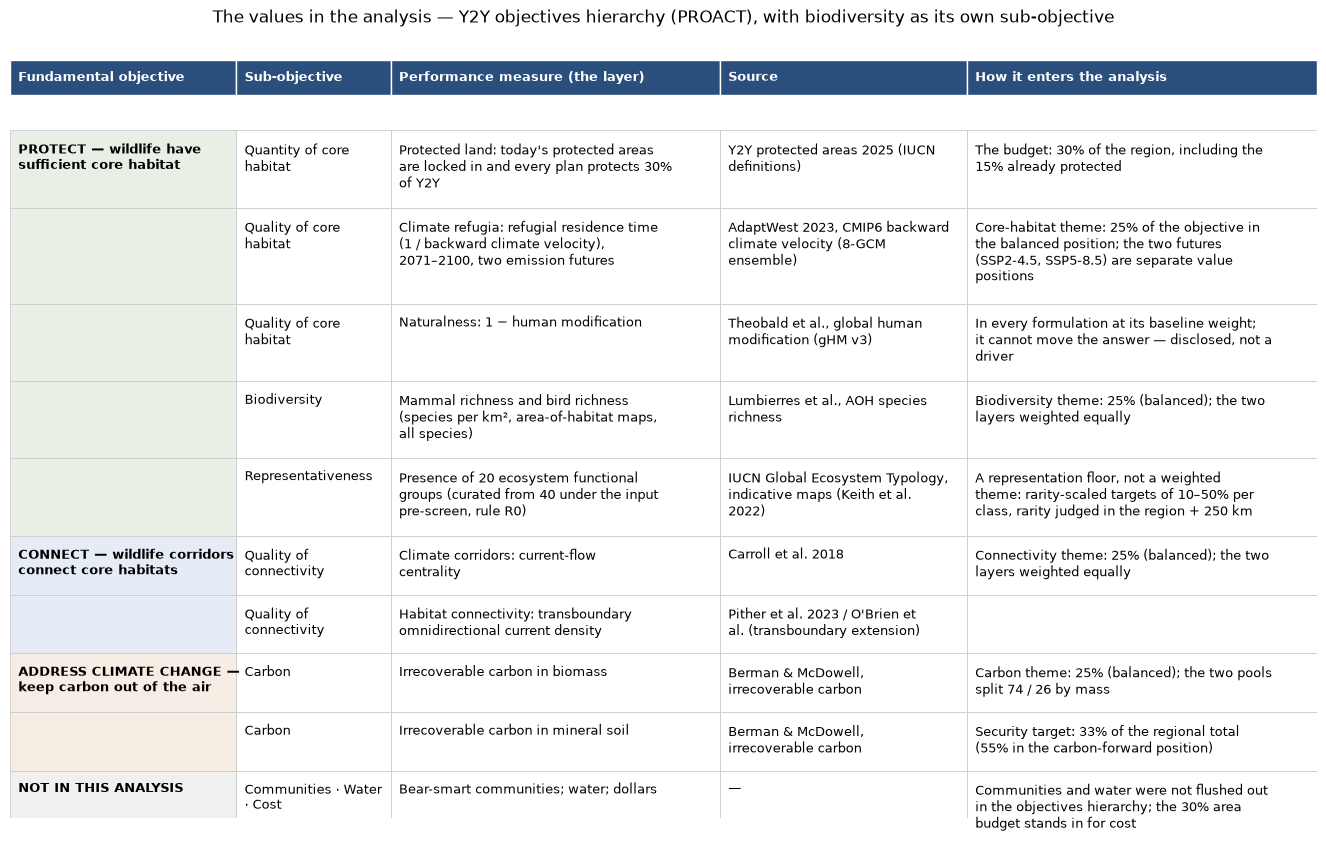

In [2]:
# ---- 1. the values in the analysis (Laura's objectives hierarchy; biodiversity as its own sub-objective) ----------
VALUES = dp.values_rows(C)
dp.grouped_table_png(VALUES, OUT / "01_values_table.png", "The values in the analysis — Y2Y objectives hierarchy (PROACT), with biodiversity as its own sub-objective")


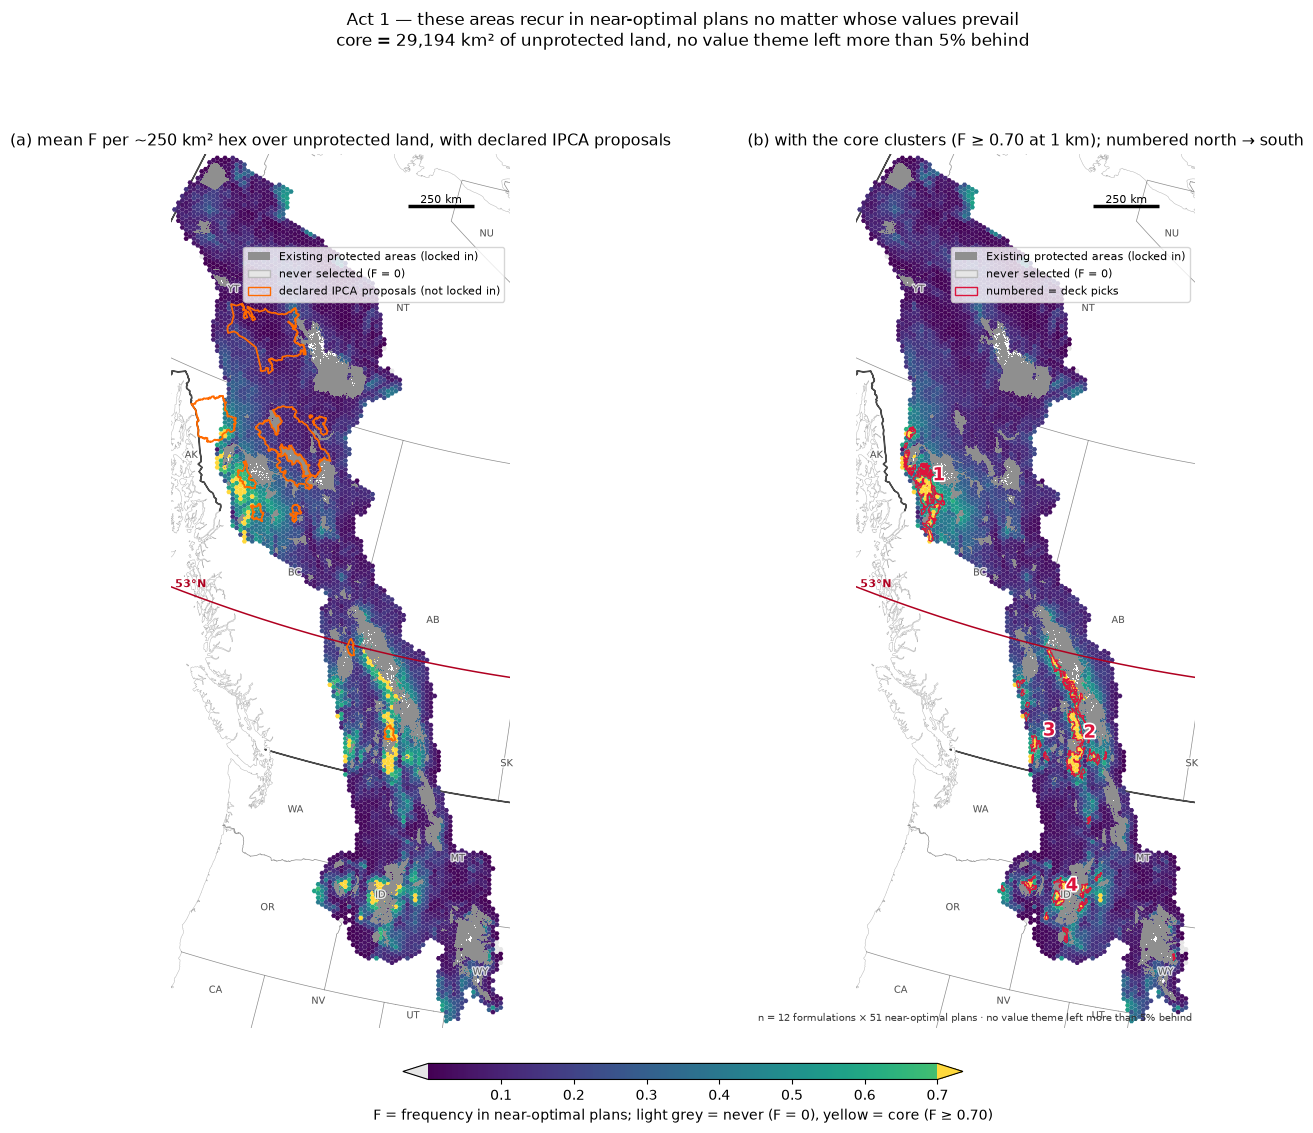

In [3]:
# ---- 2. Act 1 — the core: (a) F per ~250 km² hex, (b) with the four regional core clusters (numbered north -> south) ----
gdf, hl = HEX[dc.HEX_KM2]
hm = dc.hex_means(G, gdf, hl, Fg)
core_km2 = S["frequent_km2"]["guarded"]
fig, axes = plt.subplots(1, 2, figsize=(14, 11.5))
fig.subplots_adjust(left=0.02, right=0.98, top=0.86, bottom=0.10, wspace=0.04)
for ax, panel in zip(axes, ("a", "b")):
    draw_pa(ax); draw_hex(ax, hm, FCMAP, FNORM)
    if panel == "a":
        draw_ipca(ax)
    else:
        draw_clusters(ax, "act1", picks_for("Act 1"), fs=13)
    finish(ax, "(a) mean F per ~250 km² hex over unprotected land, with declared IPCA proposals" if panel == "a"
           else "(b) with the core clusters (F ≥ 0.70 at 1 km); numbered north → south",
           BASE_HANDLES if panel == "b" else BASE_HANDLES[:2] + [IPCA_HANDLE], note=N_NOTE if panel == "b" else "")
cax = fig.add_axes([0.30, 0.055, 0.40, 0.014])
fig.colorbar(ScalarMappable(norm=FNORM, cmap=FCMAP), cax=cax, orientation="horizontal", extend="both",
             label="F = frequency in near-optimal plans; light grey = never (F = 0), yellow = core (F ≥ 0.70)")
fig.suptitle(f"Act 1 — these areas recur in near-optimal plans no matter whose values prevail\n"
             f"core = {core_km2:,} km² of unprotected land, no value theme left more than 5% behind", fontsize=12.5, y=0.985)
fig.savefig(OUT / "02_act1_core_map.png", dpi=180, bbox_inches="tight"); plt.show()


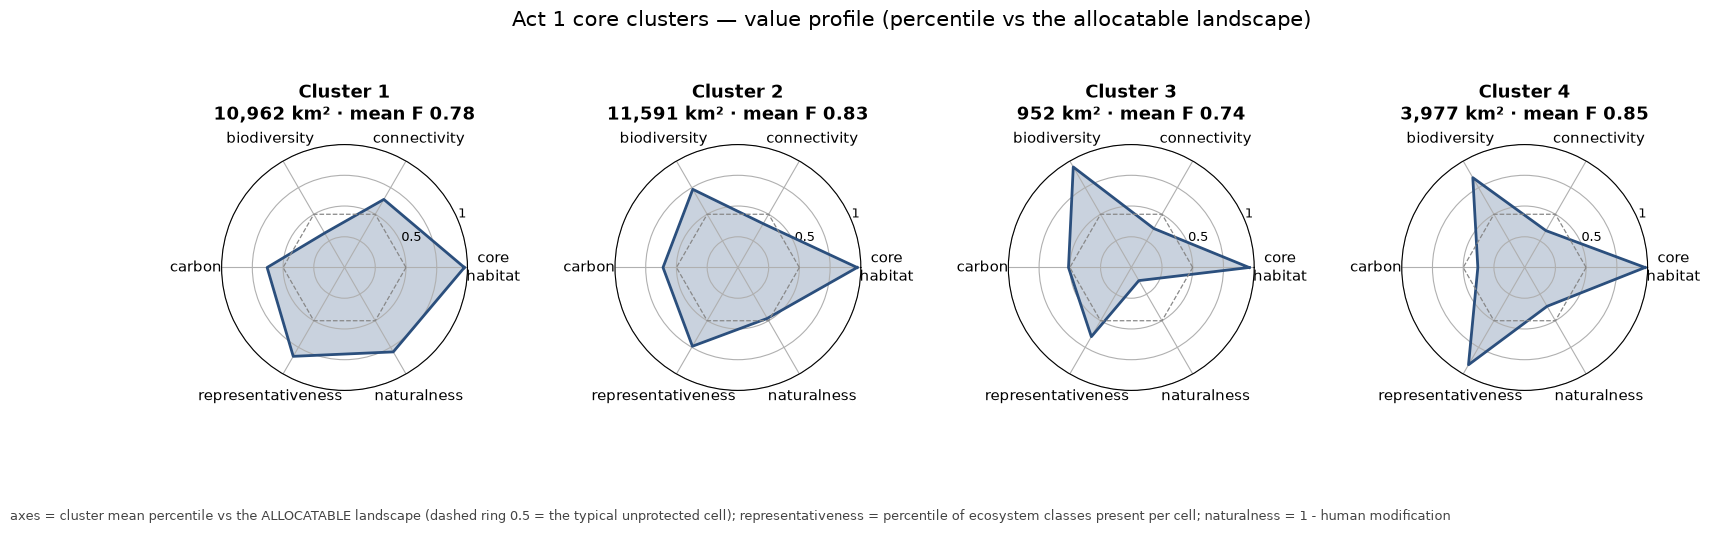

In [4]:
# ---- 3. Act 1 — star plots of the four core clusters -----------------------------------------------------------
A1 = numbered("Act 1")
dc.plot_star_grid(star_rows(A1, "#2b4f7d"), OUT / "03_act1_core_stars.png",
                  "Act 1 core clusters — value profile (percentile vs the allocatable landscape)")
plt.show()


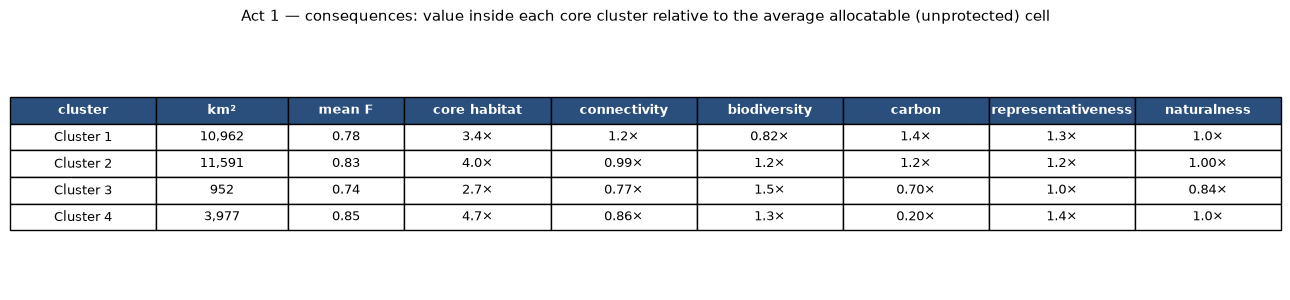

In [5]:
# ---- 4. Act 1 — consequences: mean value in the cluster / mean over allocatable land ("2.3x") -------------------
consequences_png(numbered("Act 1"), OUT / "04_act1_consequences.png",
                 "Act 1 — consequences: value inside each core cluster relative to the average allocatable (unprotected) cell")


## Next outputs to add (say the word)
Act 2 pairings (value | tier) per scenario · Act 2 stars and consequences · the hinge cross-tab · the Act 3 gap map ·
the summary tiers map · the E17 one-pager.